In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

In [6]:
df = pd.read_csv('C:/Users/User/Documents/Sample Dashboard/Sample 1/earthquake_1995-2023.csv')

In [7]:
df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


In [8]:
df.shape

(1000, 19)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1000 non-null   object 
 1   magnitude  1000 non-null   float64
 2   date_time  1000 non-null   object 
 3   cdi        1000 non-null   int64  
 4   mmi        1000 non-null   int64  
 5   alert      449 non-null    object 
 6   tsunami    1000 non-null   int64  
 7   sig        1000 non-null   int64  
 8   net        1000 non-null   object 
 9   nst        1000 non-null   int64  
 10  dmin       1000 non-null   float64
 11  gap        1000 non-null   float64
 12  magType    1000 non-null   object 
 13  depth      1000 non-null   float64
 14  latitude   1000 non-null   float64
 15  longitude  1000 non-null   float64
 16  location   994 non-null    object 
 17  continent  284 non-null    object 
 18  country    651 non-null    object 
dtypes: float64(6), int64(5), object(8)
memory usage: 

In [10]:
df.describe()

,magnitude,cdi,mmi,tsunami,sig,nst,dmin,gap,depth,latitude,longitude
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,6.940150,3.605000,6.02700,0.325000,847.915000,193.918000,1.125174,20.926290,74.612541,4.315554,51.486576
std,0.438148,3.328972,1.43399,0.468609,301.802632,239.045858,2.073164,24.415895,130.812590,26.633320,117.478302
min,6.500000,0.000000,1.00000,0.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000
25%,6.600000,0.000000,5.00000,0.000000,691.000000,0.000000,0.000000,0.000000,16.000000,-13.518500,-71.694450
50%,6.800000,4.000000,6.00000,0.000000,744.000000,0.000000,0.000000,18.000000,29.000000,-2.443500,107.791000
75%,7.100000,7.000000,7.00000,1.000000,874.250000,403.000000,1.549250,27.000000,55.000000,25.167250,148.364750
max,9.100000,9.000000,10.00000,1.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000


In [11]:
numeric = df.select_dtypes(include = ['number']).columns
print('Numeric:', numeric)

non_numeric = df.select_dtypes(exclude = ['number']).columns
print('Non-Numeric:', non_numeric)

Numeric: Index(['magnitude', 'cdi', 'mmi', 'tsunami', 'sig', 'nst', 'dmin', 'gap',
       'depth', 'latitude', 'longitude'],
      dtype='object')
Non-Numeric: Index(['title', 'date_time', 'alert', 'net', 'magType', 'location',
       'continent', 'country'],
      dtype='object')


In [12]:
#check duplicated value
df.duplicated().sum()

0

### Pre-processing 

In [13]:
# Check missing values
print(f'Number missing values in the dataset are: {sum(df.isna().sum())}')

Number missing values in the dataset are: 1622


In [14]:
df.isnull().sum()

title          0
magnitude      0
date_time      0
cdi            0
mmi            0
alert        551
tsunami        0
sig            0
net            0
nst            0
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
location       6
continent    716
country      349
dtype: int64

In [15]:
nan_columns = df.isna().any()

# Display the columns with NaN values
columns_with_nan = nan_columns[nan_columns].index.tolist()
print("Columns with NaN values:", columns_with_nan)

Columns with NaN values: ['alert', 'location', 'continent', 'country']


#### Removing column with null value > 50% 

In [16]:
df.drop(['alert', 'continent'], axis = 1, inplace = True)

In [17]:
df.head()

,title,magnitude,date_time,cdi,mmi,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN


#### Fill missing value for country

In [18]:
df['location'].str.split(pat = ',', n = 1, expand = True)

,0,1
0,Sola,Vanuatu
1,Intipucá,El Salvador
2,Loncopué,Argentina
3,Sand Point,Alaska
4,Alaska Peninsula,None
...,...,...
995,Tungor,Russia
996,Vao,New Caledonia
997,Maubara,Timor Leste
998,Aianí,Greece


In [19]:
df_new = df['location'].str.split(pat = ',', n = 1, expand = True)
df_new[1]
df['country'] = df['country'].fillna(df_new[1])
df.head()

,title,magnitude,date_time,cdi,mmi,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",El Salvador
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",Alaska
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,None


In [20]:
df.isnull().sum()

title         0
magnitude     0
date_time     0
cdi           0
mmi           0
tsunami       0
sig           0
net           0
nst           0
dmin          0
gap           0
magType       0
depth         0
latitude      0
longitude     0
location      6
country      54
dtype: int64

#### Convert Date Time to Year, Day, Month

In [21]:
df['date_time'] = pd.to_datetime(df['date_time'], dayfirst = True)


In [22]:
#extract year from date_time
df['year'] = df['date_time'].dt.year

#extract month from date_time
df['month'] = df['date_time'].dt.month

#extract day from date_time
df['day'] = df['date_time'].dt.day

In [23]:
col = df.pop('year')
df.insert(2, col.name, col)

col = df.pop('month')
df.insert(2, col.name, col)

col = df.pop('day')
df.insert(2, col.name, col)

In [24]:
df.head()

,title,magnitude,day,month,year,date_time,cdi,mmi,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16,8,2023,2023-08-16 12:47:00,7,4,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19,7,2023,2023-07-19 00:22:00,8,6,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",El Salvador
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17,7,2023,2023-07-17 03:05:00,7,5,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16,7,2023,2023-07-16 06:48:00,6,6,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",Alaska
4,M 7.3 - Alaska Peninsula,7.3,16,7,2023,2023-07-16 06:48:00,0,5,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,None


In [25]:
df.shape

(1000, 20)

#### Remove outliers

Numerical Features to be evaluated for outliers:
- cdi
- mmi
- sig
- nst
- dmin
- gap
- depth
- latitude
- longitude

<Axes: >

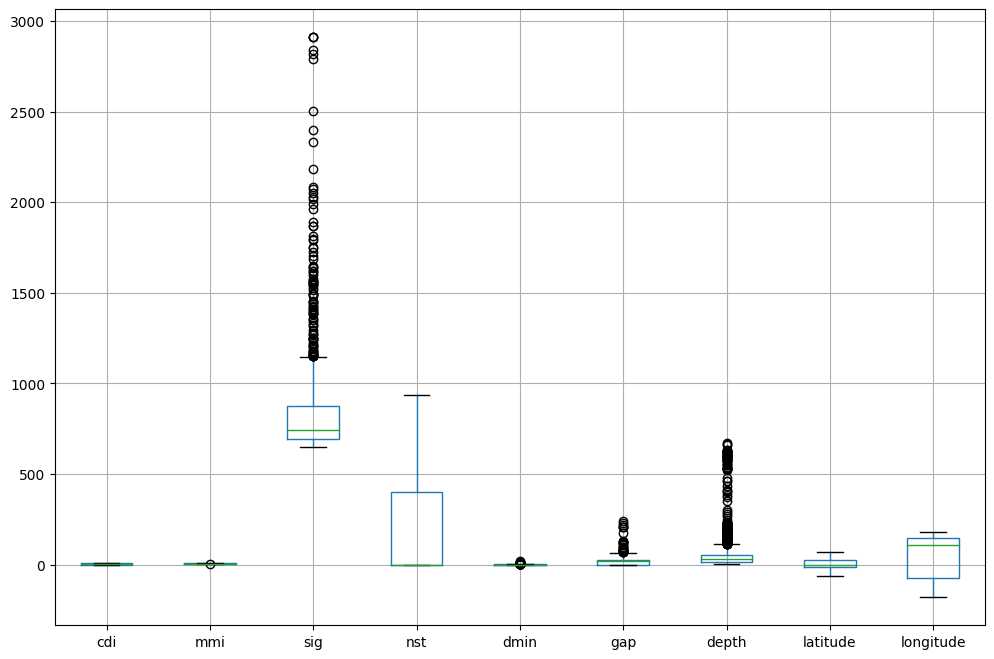

In [26]:
var = ['cdi', 'mmi','sig', 'nst', 'dmin', 'gap', 'depth', 'latitude', 'longitude']
plt.figure(figsize = (12,8))
#plt.xticks(fontsize = 7)
df.boxplot(var)

In [27]:
from scipy.stats import zscore

In [28]:
threshold = 2.5
z_scores = zscore(df['sig'])

# Keep only rows with Z-scores within the specified threshold
df_no_outliers = df[(z_scores < threshold) & (z_scores > -threshold)]

In [29]:
threshold = 3
z_scores_n = zscore(df_no_outliers['dmin'])

# Keep only rows with Z-scores within the specified threshold
df_n = df_no_outliers[(z_scores_n < threshold) & (z_scores_n > -threshold)]

In [30]:
threshold = 3
z_scores_n = zscore(df_n['gap'])

# Keep only rows with Z-scores within the specified threshold
df_n1 = df_n[(z_scores_n < threshold) & (z_scores_n > -threshold)]

In [31]:
threshold = 3
z_scores_n = zscore(df_n1['depth'])

# Keep only rows with Z-scores within the specified threshold
df = df_n1[(z_scores_n < threshold) & (z_scores_n > -threshold)]

<Axes: >

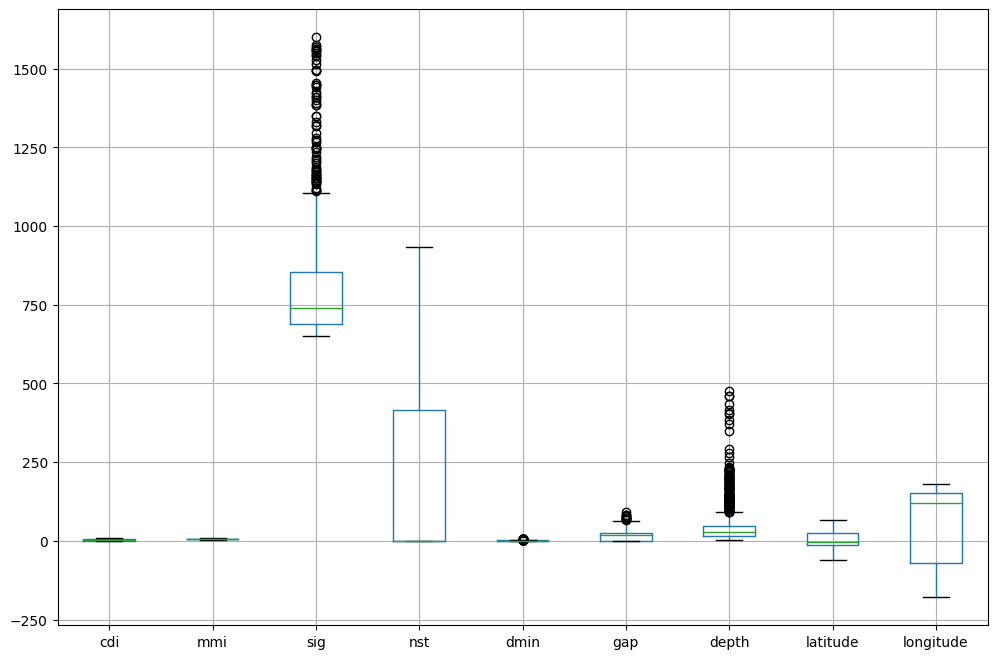

In [32]:
var = ['cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth', 'latitude', 'longitude']
plt.figure(figsize = (12,8))
df.boxplot(var)

#### Checking if data is skewed

If skewness is between -0.5 and 0.5, the distribution is approximately symmetrical.

If skewness is less than -1 or greater than 1, the distribution is highly skewed.

If skewness is between -1 and -0.5 or between 0.5 and 1, the distribution is moderately skewed.

In [33]:
skewness = df['cdi'].skew()
print("Skewness:", skewness)
# approximately symmetrical

Skewness: 0.19260571834427195


In [34]:
skewness = df['mmi'].skew()
print("Skewness:", skewness)
# moderately skewed

Skewness: -0.02880712997624665


In [35]:
skewness = df['sig'].skew()
print("Skewness:", skewness)
#highly skewed

Skewness: 2.0724695188299145


In [36]:
skewness = df['nst'].skew()
print("Skewness:", skewness)
# moderately skewed

Skewness: 0.6722718616055504


In [37]:
skewness = df['dmin'].skew()
print("Skewness:", skewness)
# highly skewed

Skewness: 2.1505025213264366


In [38]:
skewness = df['gap'].skew()
print("Skewness:", skewness)
#moderately skewed

Skewness: 0.9728732442510101


In [39]:
skewness = df['depth'].skew()
print("Skewness:", skewness)
#highly skewed

Skewness: 3.0452705431382388


In [40]:
skewness = df['latitude'].skew()
print("Skewness:", skewness)
#approximately symmetrical

Skewness: 0.3002179247625556


In [41]:
skewness = df['longitude'].skew()
print("Skewness:", skewness)
#approximately symmetrical

Skewness: -0.810391126844627


In [42]:
# Fix highly skewed data
df[['sig', 'dmin', 'depth']].apply(lambda x: np.log(x))

C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,sig,dmin,depth
0,6.487684,1.970881,5.262457
1,6.652863,-0.387134,4.244588
2,6.801283,0.491031,5.143831
3,6.756932,-0.097613,3.483422
5,6.687109,0.897719,2.302585
...,...,...,...
995,6.654153,-inf,2.397895
996,6.815640,-inf,3.005683
997,6.595781,-inf,2.415914
998,6.507278,-inf,2.639057


## Visualization

In [43]:
#color palette
my_col = ['#a1c9f4', '#8de5a1', '#ff9f9b', '#d0bbff', '#fffea3', '#b9f2f0', '#40E0D0', '#D2B48C', '#c7e9b4', '#EEE8AA', '#00FFFF', '#FAEBD7', '#FF5733', '#FF0000', '#FFA07A', '#DC143C', '#00FF00', '#008000', '#32CD32', '#228B22', '#0000FF', '#4169E1', '#87CEEB', '#1E90FF', '#800080', '#9932CC', '#8A2BE2', '#800080', '#FFA500', '#FF4500', '#FF8C00', '#D2691E', '#00CED1', '#20B2AA', '#00FFFF', '#48D1CC', '#FF00FF', '#FF69B4', '#FF1493', '#C71585', '#FFFF00', '#FFD700', '#FFFFE0', '#FFDB58', '#808080', '#A9A9A9', '#D3D3D3', '#F5F5F5', '#8B4513', '#A0522D', '#DEB887', '#D2B48C']

In [44]:
top_10 = (df['country'].value_counts()).iloc[:10]
top_10

country
Indonesia           129
Papua New Guinea     80
 Japan               43
Chile                40
Vanuatu              34
Japan                25
Solomon Islands      25
Mexico               25
 Solomon Islands     22
Peru                 22
Name: count, dtype: int64

In [45]:
fil_df = df
country_counts_df = fil_df['country'].value_counts().reset_index()
country_counts_df.columns = ['country', 'count']
country_counts_df

,country,count
0,Indonesia,129
1,Papua New Guinea,80
2,Japan,43
3,Chile,40
4,Vanuatu,34
...,...,...
87,Mongolia,1
88,Antarctica,1
89,Russian Federation (the),1
90,Antigua and Barbuda,1


In [46]:
count = df['country'].value_counts().head(20)

In [47]:
count_threshold = 5
annotated_categories = count[count > count_threshold].index

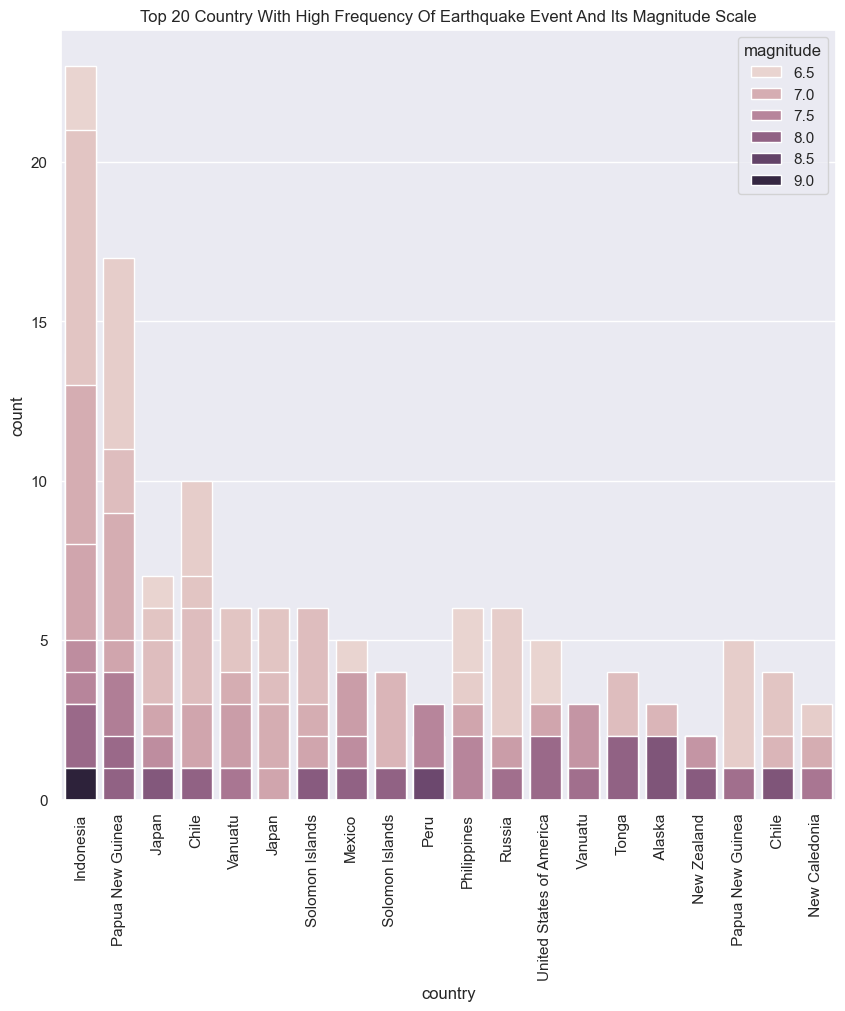

In [48]:
sns.set(style="darkgrid")
plt.figure(figsize=(10, 10))
sns.countplot(x='country', hue = 'magnitude', data=df, order=count.index, dodge = False)
        
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.title('Top 20 Country With High Frequency Of Earthquake Event And Its Magnitude Scale')
plt.show()

(([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
  [Text(0, 0, 'Indonesia'),
   Text(1, 0, 'Papua New Guinea'),
   Text(2, 0, ' Japan'),
   Text(3, 0, 'Chile'),
   Text(4, 0, 'Vanuatu'),
   Text(5, 0, 'Japan'),
   Text(6, 0, 'Solomon Islands'),
   Text(7, 0, 'Mexico'),
   Text(8, 0, ' Solomon Islands'),
   Text(9, 0, 'Peru'),
   Text(10, 0, 'Philippines'),
   Text(11, 0, 'Russia'),
   Text(12, 0, 'United States of America'),
   Text(13, 0, ' Vanuatu'),
   Text(14, 0, ' Tonga'),
   Text(15, 0, ' Alaska'),
   Text(16, 0, ' New Zealand'),
   Text(17, 0, ' Papua New Guinea'),
   Text(18, 0, ' Chile'),
   Text(19, 0, ' New Caledonia')]),
 Text(0.5, 0, ''),
 Text(0, 0.5, ''),
 ([], []))

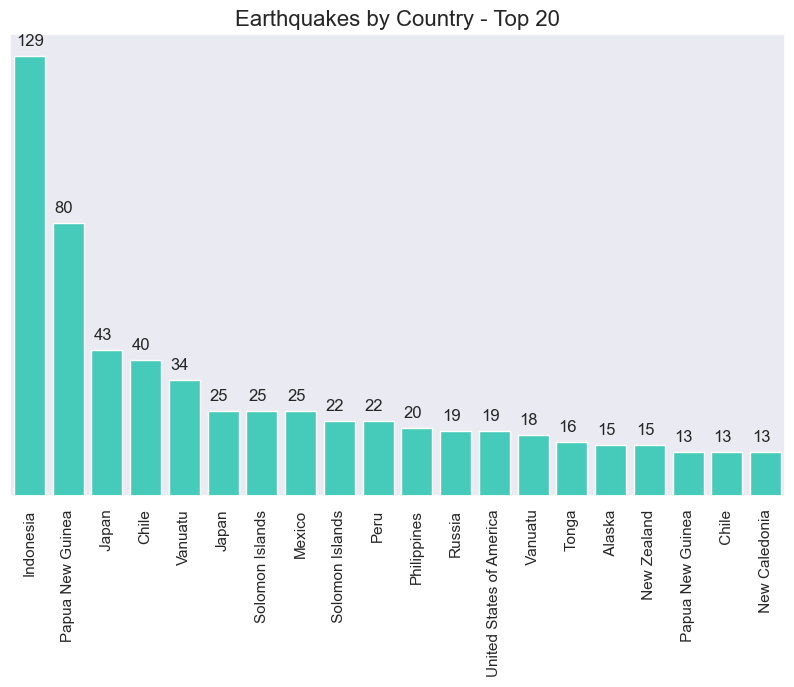

In [49]:
plt.figure(figsize = (10,6))
plt.title('Earthquakes by Country - Top 20', fontsize = 16)
ax = sns.countplot(x = df['country'], color = '#30E0CA', alpha = 1, order = df['country'].value_counts().head(20).index
                  )
for p in ax.patches:
    ax.annotate('{:.0f}'.format(p.get_height()), (p.get_x() + 0.05, p.get_height() + 3))

plt.xticks(rotation = 90), plt.xlabel(None), plt.ylabel(None), plt.yticks([])

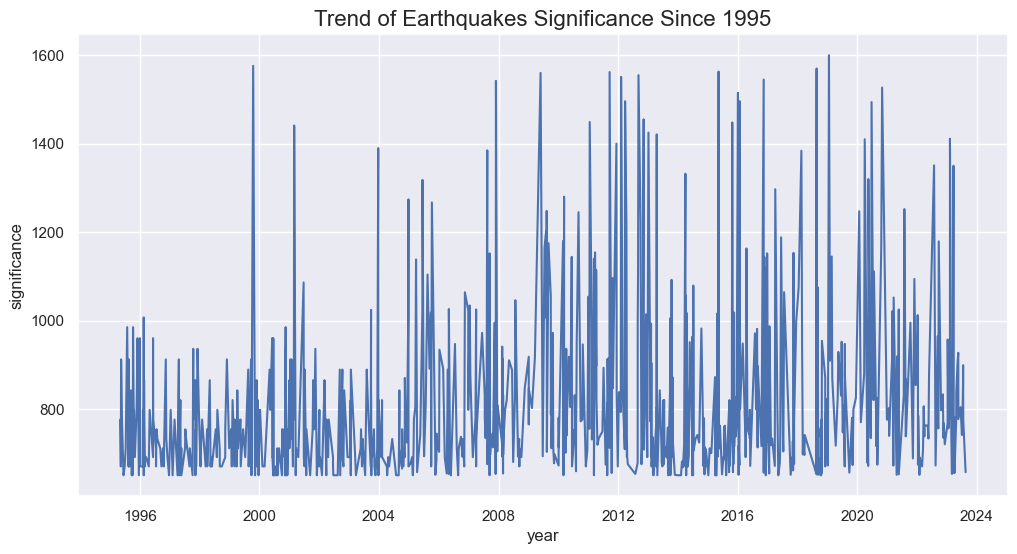

In [50]:
plt.figure(figsize=(12, 6))
plt.plot(df['date_time'], df['sig'])
plt.title('Trend of Earthquakes Significance Since 1995', fontsize=16)
plt.xlabel('year')
plt.ylabel('significance')
plt.grid(True)

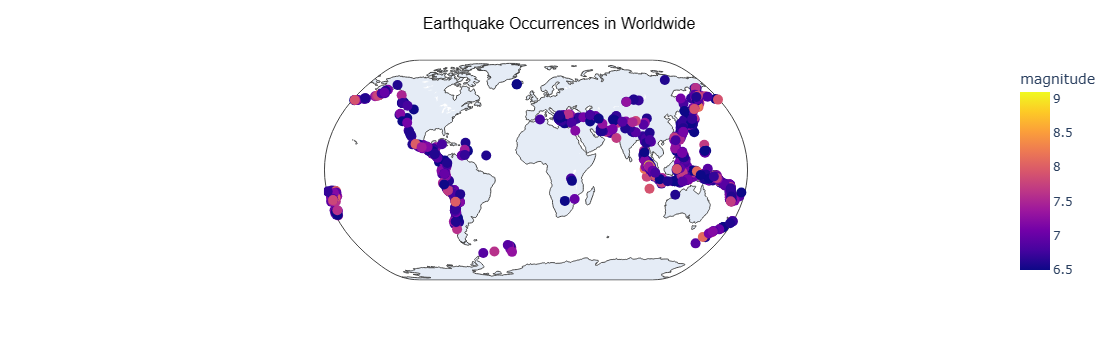

In [51]:
fig = px.scatter_geo(
    df,
    lat = 'latitude',
    lon = 'longitude',
    color = 'magnitude',
    size = 'depth',
    scope = 'world',
    projection = 'natural earth'
)

fig.update_layout(
    title = {
        'text': 'Earthquake Occurrences in Worldwide',
        'x': 0.5,
        'y': 0.95,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {
            'size': 16,
            'family': 'Arial',
            'color': 'black'
        }
    }
)

#marker size
fig.update_traces(marker = dict(size = 10))

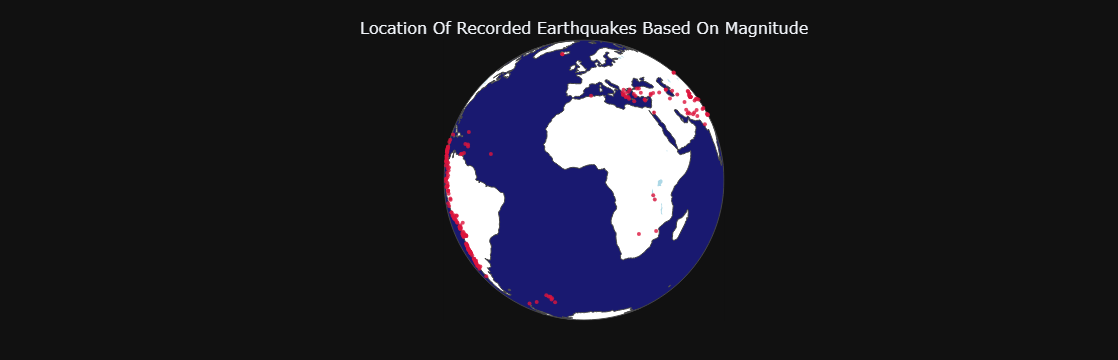

In [52]:
fig = make_subplots(
    rows = 1, cols = 1,
    specs = [[{"type": "scattergeo"}]],
    subplot_titles = ('Location Of Recorded Earthquakes Based On Magnitude',
                     )
)

fig.add_trace(
    go.Scattergeo(
        lat = df["latitude"],
        lon = df["longitude"],
        mode = "markers",
        hoverinfo = "text",
        text = df['magnitude'].astype(str) + '<br>' + df['country'], 
        showlegend = False,
        marker = dict(color = "crimson", size = 4, opacity = 0.8)
    )
)

fig.update_geos(
    projection_type = "orthographic",
    landcolor = "white",
    oceancolor = "MidnightBlue",
    showocean = True,
    lakecolor = "LightBlue"
)

fig.update_xaxes(tickangle = 45)

fig.update_layout(
    template = "plotly_dark",
    margin = dict(r = 10, t = 40, b = 40, l = 60),
)

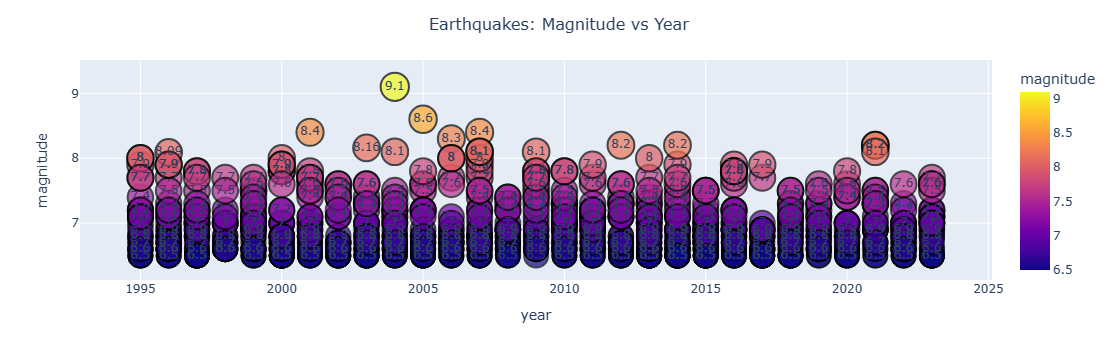

In [53]:
#scatter plot - entire DataFrame (no filter)
fig = px.scatter(
    df,
    x = 'year',
    y = 'magnitude',
    color = 'magnitude',
    text = 'magnitude',
    hover_name = 'year',
    size = 'magnitude'
)

fig.update_traces(marker = dict(line = dict(color = '#000000', width = 2)))

fig.update_layout(
    title_text = 'Earthquakes: Magnitude vs Year',
    title_x = 0.5,
    title_font = dict(size = 16)
)

In [57]:
aa = df['date_time'].value_counts()

aa = aa.resample('Y').sum().to_frame()
aa
fig = px.line(aa, x = aa.index, y = 'date_time', text = 'date_time',
             labels = {
                 'index': 'Year',
                 'date_time': 'Number of Earthquakes'
             }
             )

fig.update_traces(marker = dict(line = dict(color = '#E873E0', width = 2)))
fig.update_traces(textposition = 'top center')
fig.update_layout(title_text = 'Number of Earthquakes Anually', title_x = 0.5)

ValueError: Value of 'y' is not the name of a column in 'data_frame'. Expected one of ['count'] but received: date_time

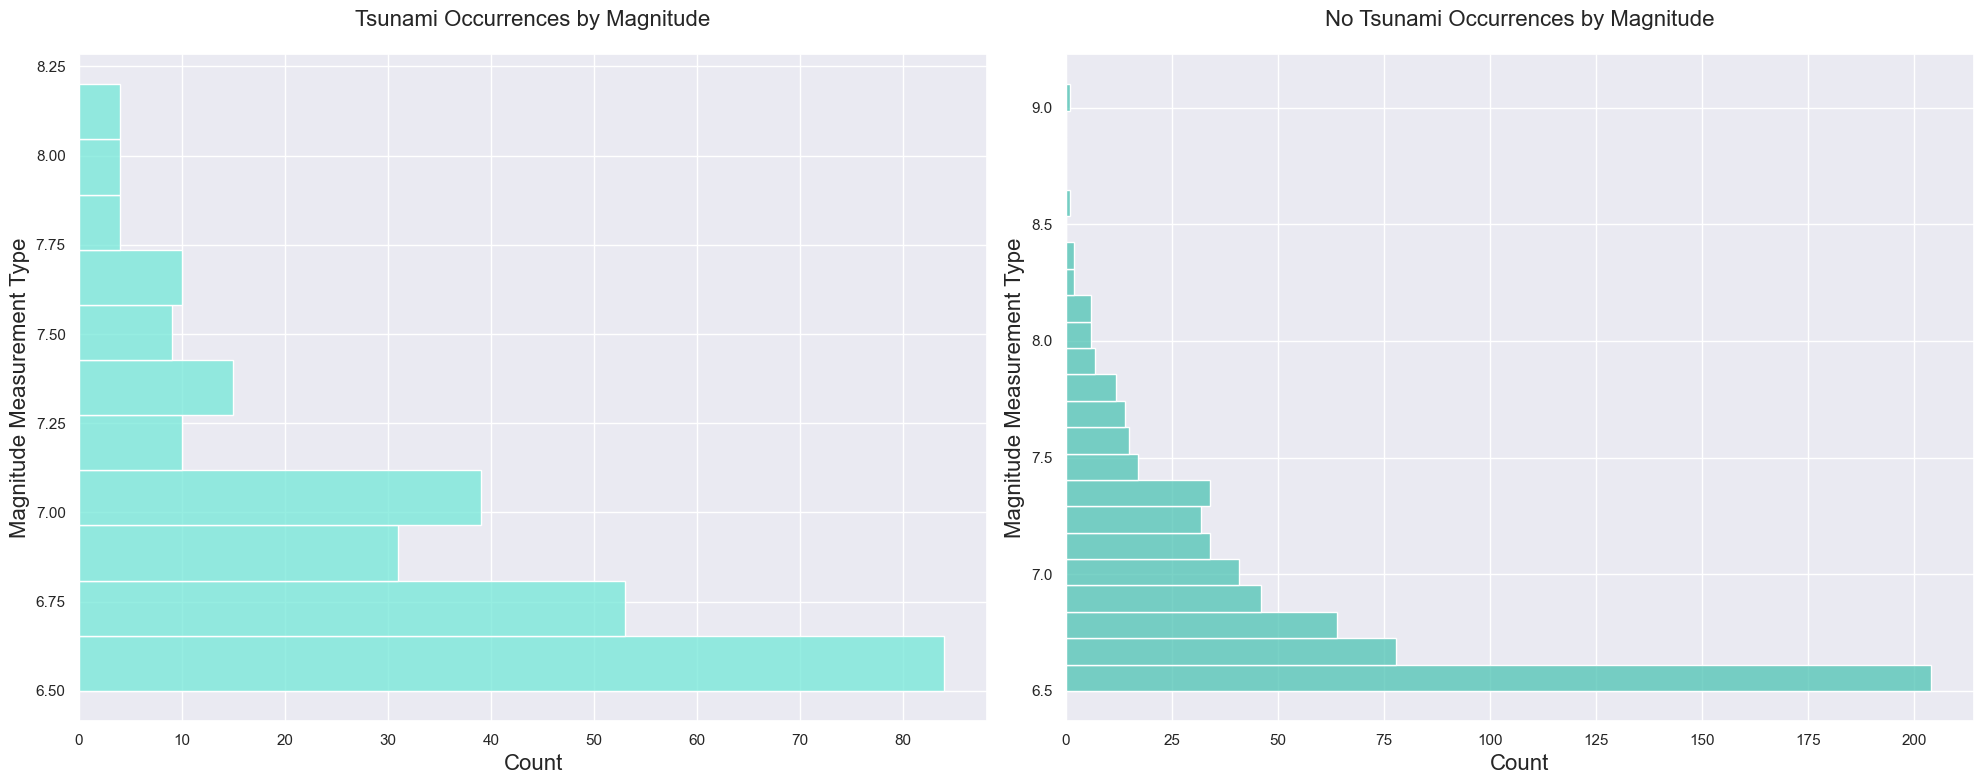

In [58]:
plt.figure(figsize = (20,8))

plt.subplot(1,2,1)
plt.title('Tsunami Occurrences by Magnitude', fontsize = 16, pad = 20)

#dataframe with tsunami
tsunami = df[df['tsunami'] == 1]
sns.histplot(data = tsunami, y = 'magnitude', color = '#73E8D8')
plt.xlabel('Count', fontsize = 16)
plt.ylabel('Magnitude Measurement Type', fontsize = 16)

#data without tsunami
plt.subplot(1,2,2)
plt.title('No Tsunami Occurrences by Magnitude', fontsize = 16, pad = 20)

no_tsunami = df[df['tsunami'] == 0]
sns.histplot(data = no_tsunami, y = 'magnitude', color = '#4EC4B4')
plt.xlabel('Count', fontsize = 16)
plt.ylabel('Magnitude Measurement Type', fontsize = 16)

plt.tight_layout()

C:\Users\User\AppData\Local\Temp\ipykernel_27020\2693348458.py:4: UserWarning:

The palette list has more values (52) than needed (8), which may not be intended.



Text(0.5, 0, 'Tsunami Occurrence (0 = No, 1 = Yes)')

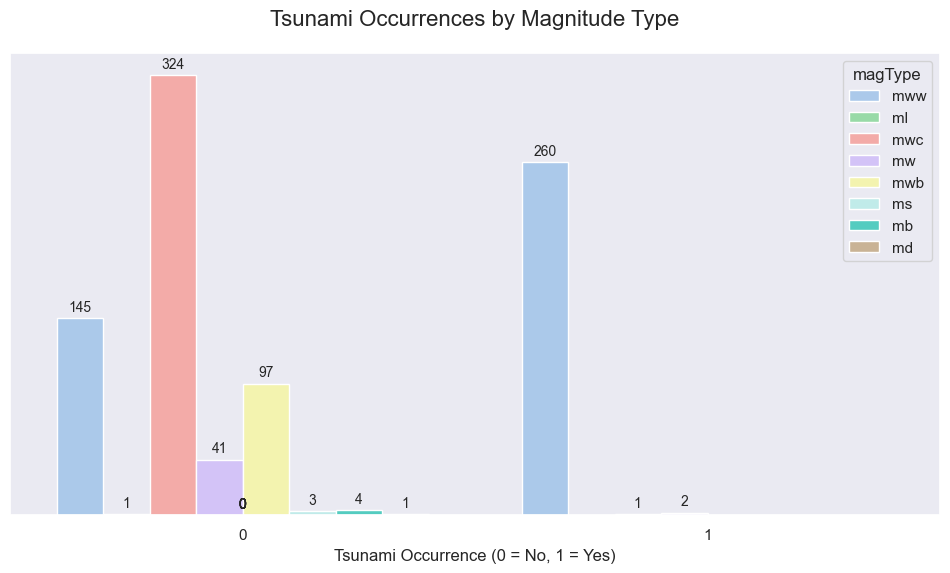

In [59]:
plt.figure(figsize = (12,6))
plt.title('Tsunami Occurrences by Magnitude Type', pad = 20, fontsize = 16)

ax = sns.countplot(data = df, x = 'tsunami', hue = 'magType', palette = my_col)

#add labels to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2, p.get_height() + 5), ha = 'center', fontsize = 10)

ax.set_ylabel(None)
ax.yaxis.set_major_locator(plt.NullLocator())

ax.set_xlabel('Tsunami Occurrence (0 = No, 1 = Yes)', fontsize = 12)

C:\Users\User\AppData\Local\Temp\ipykernel_27020\2660824046.py:5: UserWarning:

FixedFormatter should only be used together with FixedLocator



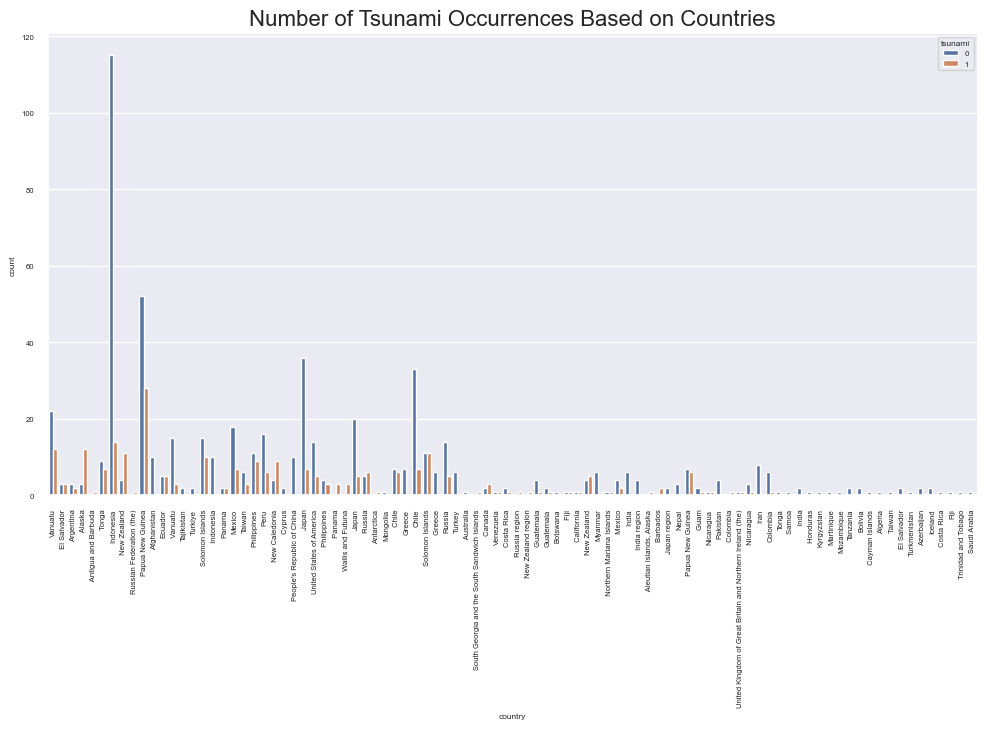

In [60]:
plt.figure(figsize = (12,6))
sns.set(font_scale=0.5)
sbd = sns.countplot(data = df, x = 'country', hue = 'tsunami')
plt.title('Number of Tsunami Occurrences Based on Countries', fontsize=16)
sbd.set_xticklabels(sbd.get_xticklabels(), rotation=90)
plt.show()

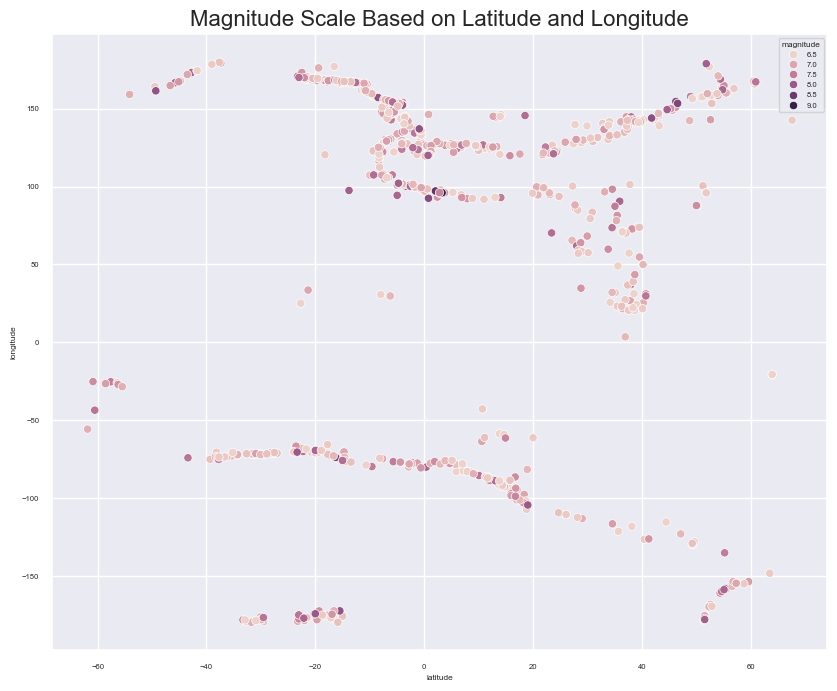

In [61]:
plt.figure(figsize=(10, 8))
plt.title('Magnitude Scale Based on Latitude and Longitude', fontsize=16)
sns.scatterplot(data=df,
               x='latitude',
               y='longitude',
               hue='magnitude')
plt.show()

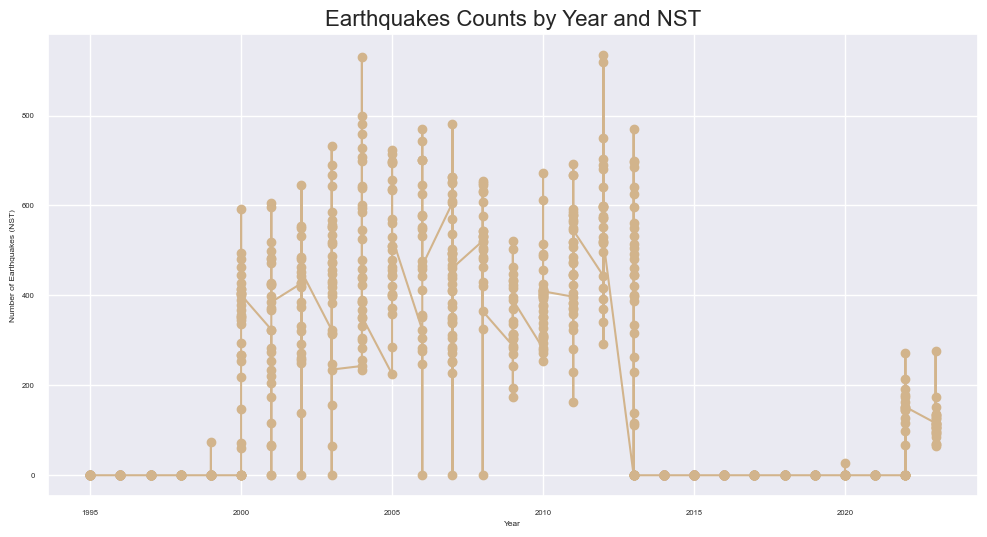

In [62]:
plt.figure(figsize = (12,6))
plt.plot(df['year'], df['nst'], marker = 'o', linestyle = '-', color = my_col[7])
plt.title('Earthquakes Counts by Year and NST', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes (NST)')
plt.grid(True)

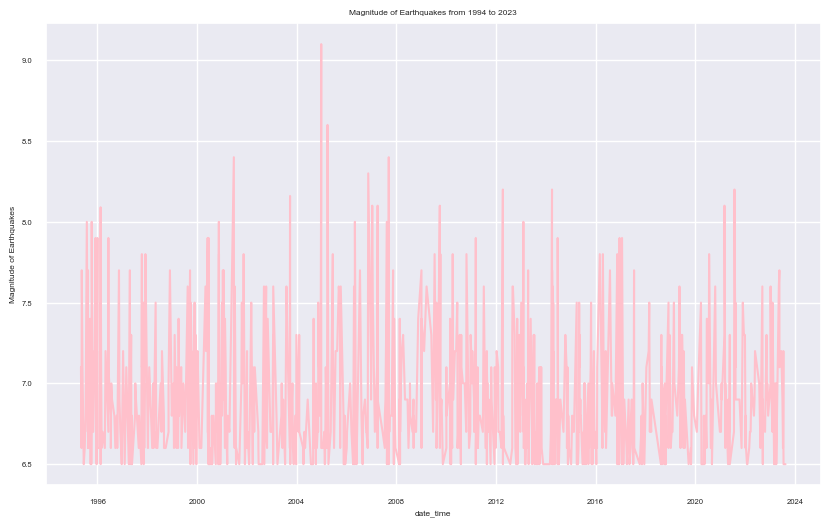

In [63]:
#time series
def plot_df(df, x, y, title = "", xlabel = 'date_time', ylabel = 'Magnitude of Earthquakes', dpi = 100):
    plt.figure(figsize = (10,6), dpi = dpi)
    plt.plot(x, y, color = 'pink')
    plt.gca().set(title = title, xlabel = xlabel, ylabel = ylabel)
    plt.show()
    
plot_df(df, x = df['date_time'], y = df['magnitude'], title = 'Magnitude of Earthquakes from 1994 to 2023')

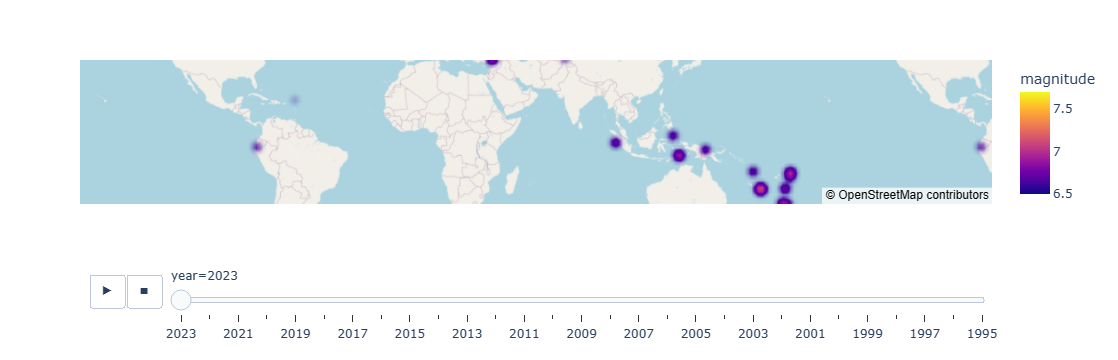

In [64]:
fig = px.density_mapbox(df, lat = 'latitude', lon = 'longitude', z = 'magnitude', mapbox_style = 'open-street-map', animation_frame = 'year', zoom = 0.5, radius = 10)
fig.show()

In [65]:
plt.figure(figsize = (15,8))
correlation = sns.heatmap(df.corr(), vmin = -1, vmax = 1, annot = True, linewidths = 1, linecolor = 'black')
correlation.set_title('Correlation Graph of the Dataset', fontdict = {'fontsize': 22})

ValueError: could not convert string to float: 'M 6.5 - 42 km W of Sola, Vanuatu'

<Figure size 1500x800 with 0 Axes>

strongest correlation with magnitude = sig, mmi
strongest correlation with year = cdi, tsunami, dmin, gap

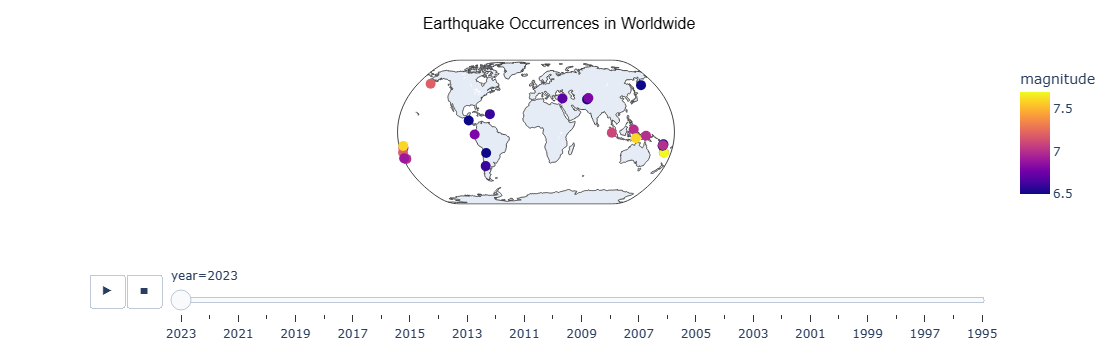

In [68]:
fig = px.scatter_geo(
    df,
    lat = 'latitude',
    lon = 'longitude',
    color = 'magnitude',
    size = 'depth',
    scope = 'world',
    projection = 'natural earth',
    animation_frame = 'year'
)

fig.update_layout(
    title = {
        'text': 'Earthquake Occurrences in Worldwide',
        'x': 0.5,
        'y': 0.95,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {
            'size': 16,
            'family': 'Arial',
            'color': 'black'
        }
    }
)

#marker size
fig.update_traces(marker = dict(size = 10))

## Predicting earthquake model

In [69]:
df_n = df[['latitude', 'longitude', 'magnitude', 'sig']].dropna()

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df_n[['latitude', 'longitude', 'sig']], df_n['magnitude'], test_size=0.2, random_state=42)

### Random forest

In [70]:
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

RandomForestRegressor()

In [71]:
from sklearn.metrics import r2_score, mean_squared_error

scores= {"Model name": ["Random Forest", "K-Nearest", "Multi-Linear"], "mse": [], "R^2": []}

In [72]:
y_pred = rf_model.predict(X_test)

# Evaluate the performance of the model using mean squared error and R^2 score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

scores['mse'].append(mse)
scores['R^2'].append(r2)

print('Mean Squared Error: ', mse)
print('R^2 Score: ', r2)

Mean Squared Error:  0.0485132320454545
R^2 Score:  0.7252609135677881


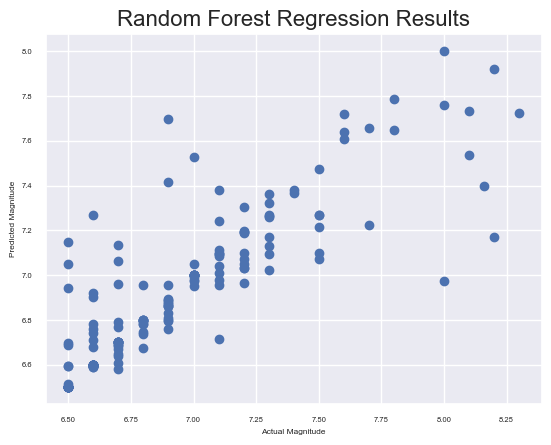

In [73]:
y_pred = rf_model.predict(X_test)
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Random Forest Regression Results', fontsize=16)
plt.show()

### K-nearest

In [74]:
model_k = KNeighborsRegressor()
model_k.fit(X_train, y_train)

# #Training
k_accuracy = model_k.score(X_train, y_train)

# #Testing
k_test_accuracy = model_k.score(X_test, y_test)

print("Training Accuracy:", k_accuracy)
print("Testing Accuracy:", k_test_accuracy)

Training Accuracy: 0.7237907797752393
Testing Accuracy: 0.5635797722735352


In [75]:
y_pred_knn = model_k.predict(X_test)

# Evaluate the performance of the model using mean squared error and R^2 score
mse = mean_squared_error(y_test, y_pred_knn)
r2 = r2_score(y_test, y_pred_knn)

scores['mse'].append(mse)
scores['R^2'].append(r2)

print('Mean Squared Error: ', mse)
print('R^2 Score: ', r2)

Mean Squared Error:  0.0770627727272727
R^2 Score:  0.5635797722735352


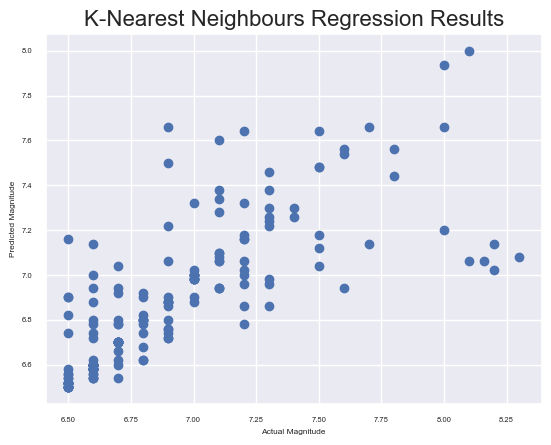

In [76]:
y_pred_knn_1 = model_k.predict(X_test)
plt.scatter(y_test, y_pred_knn_1)
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('K-Nearest Neighbours Regression Results', fontsize=16)
plt.show()

### Linear Regression

In [77]:
# Train the linear regression model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [78]:
y_pred_l = regressor.predict(X_test)

# Compute R^2 and MSE
mse = mean_squared_error(y_test, y_pred_l)
r2 = r2_score(y_test, y_pred_l)

scores['mse'].append(mse)
scores['R^2'].append(r2)

print('Mean Squared Error: ', mse)
print('R^2 Score: ', r2)

Mean Squared Error:  0.10217784588061826
R^2 Score:  0.4213486332027908


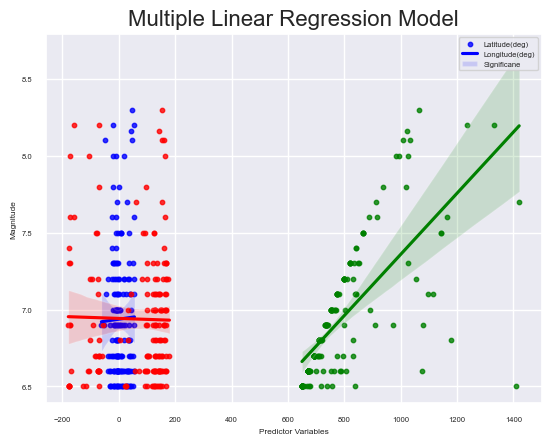

In [79]:
# Plot the regression line
sns.regplot(x=X_test['latitude'], y=y_test, color='blue', scatter_kws={'s': 10})
sns.regplot(x=X_test['longitude'], y=y_test, color='red', scatter_kws={'s': 10})
sns.regplot(x=X_test['sig'], y=y_test, color='green', scatter_kws={'s': 10})
plt.legend(labels=['Latitude(deg)', 'Longitude(deg)', 'Significane'])
plt.xlabel('Predictor Variables')
plt.ylabel('Magnitude')
plt.title('Multiple Linear Regression Model', fontsize=16)
plt.show()
     

#### Evaluate model scores

In [80]:
scores_df = pd.DataFrame(scores)
display(scores_df)

,Model name,mse,R^2
0,Random Forest,0.048513,0.725261
1,K-Nearest,0.077063,0.563580
2,Multi-Linear,0.102178,0.421349


In [81]:
scores_df[scores_df["mse"] == scores_df["mse"].min()]

,Model name,mse,R^2
0,Random Forest,0.048513,0.725261


In [82]:
scores_df[scores_df["R^2"] == scores_df["R^2"].max()]


,Model name,mse,R^2
0,Random Forest,0.048513,0.725261


From the above result, Random Forest regression have the most accurate result with the highest r^2 score and the lowest MSE. Hence, for the sake of the context of this research, we decided that Random Forest Regression is the most suitable model for predicting the magnitude of Earthquake.

### Testing prediction model with random forest

Testing with Shibuya, Tokyo, Japan coordinates:
latitude = 36.6
longitude = 139.7

In [83]:
# Features and target variable
X = df[['latitude', 'longitude', 'sig']]
y = df['magnitude']


In [84]:
### Model pipeline
model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Fit the model
model.fit(X, y)

print('Earthquake Magnitude Prediction')

lat = input('Enter Latitude: ')
long =input('Enter Longitude: ')

new_location = [[lat, long, 0]]
predicted_magnitude = model.predict(new_location)[0]

# Display the predicted magnitude
print(f'Predicted Magnitude: {predicted_magnitude:.2f}')


Earthquake Magnitude Prediction


Enter Latitude:  123
Enter Longitude:  31


Predicted Magnitude: 6.50


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:465: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



### Hyperparameter Tuning

In [85]:
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred)

scores['mse'].append(mse_rf)
scores['R^2'].append(r2_rf)

print('Mean Squared Error: ', mse_rf)
print('R^2 Score: ', r2_rf)

Mean Squared Error:  0.04705585511363635
R^2 Score:  0.7252609135677881


In [87]:
rf_model = RandomForestRegressor()

# Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Use GridSearchCV to perform hyperparameter tuning
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, 
                           scoring='neg_mean_squared_error', cv=5, n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")

# Evaluate the model with the best hyperparameters on the test set
best_rf_model = grid_search.best_estimator_
y_pred = best_rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error on Test Set: {mse}")

Best Hyperparameters: {'max_depth': 30, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 10}
Mean Squared Error on Test Set: 0.056286214734647365


In [88]:
r2_n = r2_score(y_test, y_pred)
print(f"R-Squared Score on Test Set: {r2_n}")

R-Squared Score on Test Set: 0.681241126123378


In [89]:
scores = pd.DataFrame({
    'Scores': ['With Hyperparameter Tuning','Without Hyperparameter Tuning'],
    
    'Score': [r2_n, r2_rf]})

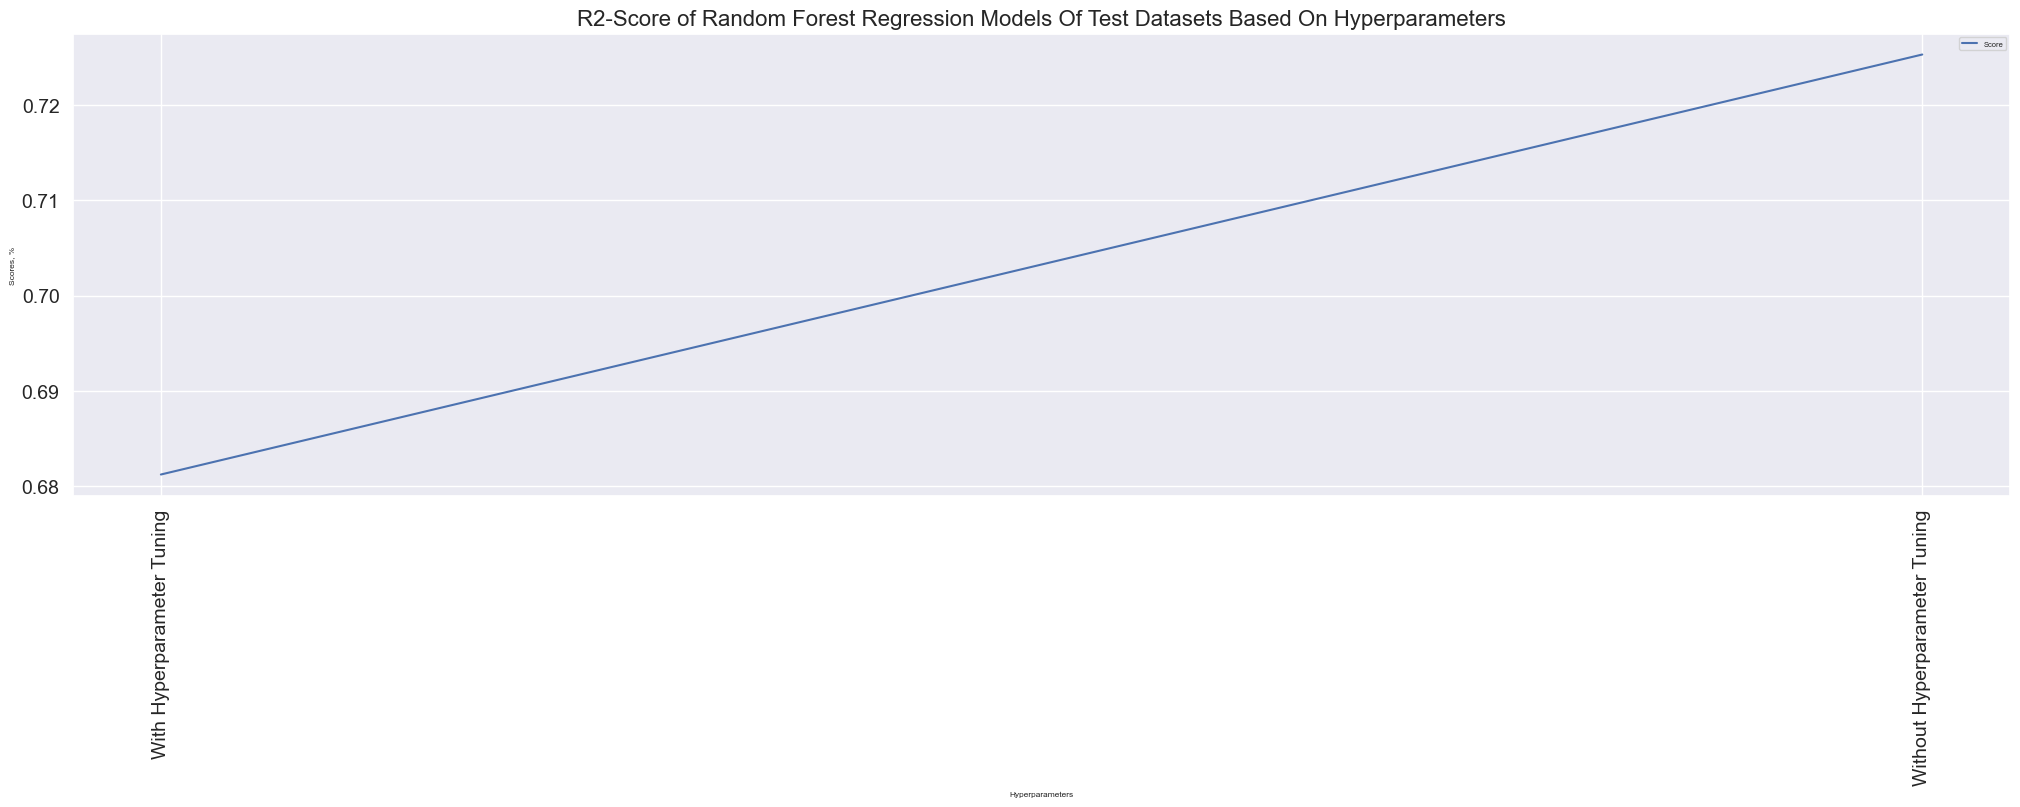

In [90]:
plt.figure(figsize=[25,6])
xx = scores['Scores']
plt.tick_params(labelsize=14)
plt.plot(xx, scores['Score'], label = 'Score')
plt.legend()
plt.title('R2-Score of Random Forest Regression Models Of Test Datasets Based On Hyperparameters', fontsize=16)
plt.xlabel('Hyperparameters')
plt.ylabel('Scores, %')
plt.xticks(xx, rotation='vertical')
plt.show()